### 1. Импорт и ограничения

In [48]:
# Импорт и базовый setup
import sys
import os
import torch
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from tqdm.auto import trange
import matplotlib.pyplot as plt
from IPython.display import display

# Проверка устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Указываем модели (чекпоинты, используемые в демо)
EMB_MODEL = 'ibm-research/MoLFormer-XL-both-10pct'
GEN_MODEL = 'ibm-research/GP-MoLFormer-Uniq'

# Загрузка токенизатора и моделей (это занимает время)
print('Loading tokenizer and embedding model...')
tokenizer = AutoTokenizer.from_pretrained(EMB_MODEL, trust_remote_code=True)
emb_model = AutoModel.from_pretrained(EMB_MODEL, trust_remote_code=True).to(device)
emb_model.eval()

print('Loading generative model...')
gen_model = AutoModelForCausalLM.from_pretrained(GEN_MODEL, trust_remote_code=True).to(device)
gen_model.eval()

Device: cuda
Loading tokenizer and embedding model...


D:\Program\Anaconda\envs\gp-molformer\lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading generative model...


MolformerForCausalLM(
  (molformer): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
         

In [2]:
# Подавление предупреждений
import warnings
from transformers import logging as transformers_logging

# Отключаем конкретное предупреждение про attention
warnings.filterwarnings('ignore', message='Outputting attentions in linear attention')

# Устанавливаем минимальный уровень логирования для transformers
transformers_logging.set_verbosity_error()

# Если хотите видеть только ошибки, но не предупреждения
transformers_logging.disable_progress_bar()
transformers_logging.set_verbosity_error()

print("Предупреждения от transformers подавлены")

Предупреждения от transformers подавлены


In [3]:
# Функция-обертка для подавления вывода
from io import StringIO
from contextlib import redirect_stderr

# Набор молекул для примера
molecules = {
    'naproxen': 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',
    'ketoprofen': 'CC(C1=CC(=CC=C1)C(=O)C2=CC=CC=C2)C(=O)O',
    'ibuprofen': 'C[C@H](C1=CC=C(C=C1)CC(C)C)C(=O)O',
    'flurbiprofen': 'CC(C1=CC(=C(C=C1)C2=CC=CC=C2)F)C(=O)O'
}
def get_embedding_and_tokens_v2(smiles, agg='mean'):
    with redirect_stderr(StringIO()):  # Перенаправляем stderr в никуда
        inputs = tokenizer(smiles, return_tensors='pt').to(device)
        input_ids = inputs['input_ids'].squeeze(0).cpu().tolist()
        tokens = tokenizer.convert_ids_to_tokens(input_ids)
        
        with torch.no_grad():
            outputs = emb_model(**inputs, output_attentions=True)
        
        last_hidden = outputs.last_hidden_state.squeeze(0).cpu().numpy()
        
        if last_hidden.shape[0] != len(tokens):
            tokens = tokens[: last_hidden.shape[0]]
            
        emb = last_hidden.mean(axis=0) if agg=='mean' else last_hidden[0]
        attentions = outputs.attentions if hasattr(outputs, 'attentions') else None
        
        return emb, last_hidden, tokens, attentions

# Сбор эмбеддингов для набора
print("Вычисляем эмбеддинги для демо-молекул...")
embeddings = {}
token_info = {}
attentions_info = {}

for name, smi in molecules.items():
    emb, token_embs, tokens, atts = get_embedding_and_tokens_v2(smi)
    embeddings[name] = emb
    token_info[name] = {'tokens': tokens, 'token_embs': token_embs}
    attentions_info[name] = atts

Вычисляем эмбеддинги для демо-молекул...


### 2. Визуализация

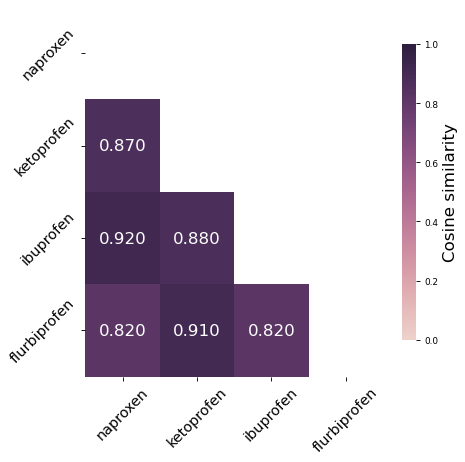

In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(6, 6), dpi=80)

names = list(embeddings.keys())
emb_matrix = np.vstack([embeddings[n] for n in names])
sim_matrix = cosine_similarity(emb_matrix)

triangle = np.triu(sim_matrix)

sns.heatmap(
    sim_matrix.round(2),
    xticklabels=names, 
    yticklabels=names, 
    annot=True, 
    fmt='.3f',
    mask = triangle,
    cmap=sns.cubehelix_palette(as_cmap=True),
    vmin=0, vmax=1,
    annot_kws={'size': 15},
    cbar_kws={'label': 'Cosine similarity', 'shrink': 0.8})

ax.tick_params(axis='x', labelsize=13, rotation=45)
ax.tick_params(axis='y', labelsize=13, rotation=45)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Cosine similarity', fontsize=15)

ax.grid(False)
#fig.show()

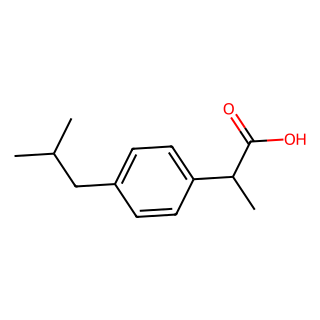

In [5]:
naproxen_smiles = 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O'
nap_mol = Chem.MolFromSmiles(naproxen_smiles)
# Конвертируем в изображение и показываем
img = Draw.MolToImage(nap_mol, size=(320,320))
display(img)

### 3. Генерация молекул

In [6]:
def generate_smiles(fragment, batch_size=20, temperature=1.0, max_length=None, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if max_length is None:
        try:
            max_length = gen_model.config.max_position_embeddings
        except Exception:
            max_length = 256
    inputs = tokenizer(fragment, return_tensors='pt').to(device)
    with torch.no_grad():
        out = gen_model.generate(
            **inputs,
            do_sample=True,
            temperature=temperature,
            top_p=0.95,
            max_length=max_length,
            num_return_sequences=batch_size,
            pad_token_id=tokenizer.eos_token_id
        ).cpu()
    decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
    cleaned = [d.strip().split()[0] for d in decoded if isinstance(d, str) and d.strip()]
    return cleaned

In [123]:
# Генерируем на разных температурах
temps = [t.round(2) for t in np.linspace(start=.1,stop=1.2,num=50)]
results = {}
for t in temps:
    gen = generate_smiles(molecules['naproxen'], batch_size=1000, temperature=t, seed=1)
    valid = [s for s in gen if Chem.MolFromSmiles(s)]
    results[t] = {'raw': gen, 'valid': valid}

[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom # 14 O, 4, is greater than permitted
[21:23:46] Explicit valence for atom #

In [136]:
valid_smiles_list = []
temperature_list = []

for t in temps:
    valid_mols = results[t]['valid']
    valid_smiles_list.extend(valid_mols)
    temperature_list.extend([t] * len(valid_mols))
    print(f"Temp={t}: generated={len(results[t]['raw'])}, valid={len(valid_mols)}, unique_valid={len(set(valid_mols))}")

valid_mol = pd.DataFrame({
    'SMILES': valid_smiles_list,
    'Temperature': temperature_list
})
gen_mols_df = valid_mol.drop_duplicates(subset='SMILES', keep='first').reset_index(drop=True)
gen_mols_df['mol']=gen_mols_df['SMILES'].apply(Chem.MolFromSmiles)
print(f'\nВсего валидных молекул (без дубликатов): {len(gen_mols_df)}')

Temp=0.1: generated=1000, valid=0, unique_valid=0
Temp=0.12: generated=1000, valid=0, unique_valid=0
Temp=0.14: generated=1000, valid=0, unique_valid=0
Temp=0.17: generated=1000, valid=0, unique_valid=0
Temp=0.19: generated=1000, valid=0, unique_valid=0
Temp=0.21: generated=1000, valid=0, unique_valid=0
Temp=0.23: generated=1000, valid=0, unique_valid=0
Temp=0.26: generated=1000, valid=0, unique_valid=0
Temp=0.28: generated=1000, valid=0, unique_valid=0
Temp=0.3: generated=1000, valid=0, unique_valid=0
Temp=0.32: generated=1000, valid=0, unique_valid=0
Temp=0.35: generated=1000, valid=0, unique_valid=0
Temp=0.37: generated=1000, valid=0, unique_valid=0
Temp=0.39: generated=1000, valid=0, unique_valid=0
Temp=0.41: generated=1000, valid=0, unique_valid=0
Temp=0.44: generated=1000, valid=32, unique_valid=7
Temp=0.46: generated=1000, valid=34, unique_valid=8
Temp=0.48: generated=1000, valid=37, unique_valid=9
Temp=0.5: generated=1000, valid=41, unique_valid=10
Temp=0.53: generated=1000, va

[21:45:45] WARNING: not removing hydrogen atom without neighbors
[21:45:45] WARNING: not removing hydrogen atom without neighbors
[21:45:45] WARNING: not removing hydrogen atom without neighbors
[21:45:45] WARNING: not removing hydrogen atom without neighbors
[21:45:45] WARNING: not removing hydrogen atom without neighbors
[21:45:45] WARNING: not removing hydrogen atom without neighbors


In [137]:
gen_mols_df.sample(10)

,SMILES,Temperature,mol
473,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OOC(=O)C1=Cc2ccccc...,1.18,<rdkit.Chem.rdchem.Mol object at 0x0000022004A...
465,CC(C)CC1=CC=C(C=C1)C(C)C(=O)Oc1c(Br)cc(F)cc1Br,1.18,<rdkit.Chem.rdchem.Mol object at 0x0000022004A...
264,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OOCCOCCOCCOCCOC(=O...,1.00,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...
449,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OCCCC(=O)OCCCC(=O)...,1.18,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...
133,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OOC(=O)C1=CC=CCC1C,0.89,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...
375,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OOc1cccc2c1OC1C(=O...,1.11,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...
274,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OOC(=O)c1c(C2=CCC(...,1.02,<rdkit.Chem.rdchem.Mol object at 0x0000022003E...
194,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OC(C)(C)C.CCCC,0.95,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...
106,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OC1C(=CC(C)C)C1C,0.86,<rdkit.Chem.rdchem.Mol object at 0x0000022003E...
365,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OOC1=CCC(C2C=CC(C(...,1.11,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...


### 4. Фильтрация сгенерированных молекул

#### Базовые фильтры

In [143]:
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from rdkit.Chem import Descriptors, Lipinski, Crippen, QED, rdMolDescriptors

def calc_qed(mol):
    if mol is None:
        return 0.0
    try:
        result = QED.qed(mol)
        if result is None:
            return 0.0
        return float(result)
    except Exception as e:
        return 0.0


def calc_sa(mol):
    if mol is None:
        return 10.0
    num_rings = rdMolDescriptors.CalcNumRings(mol)
    num_rotatable = Descriptors.NumRotatableBonds(mol)
    mw = Descriptors.MolWt(mol)

    score = 1.0 + (num_rings * 0.4) + (num_rotatable * 0.1) + (mw / 150.0)
    return min(10.0, max(1.0, score))


params_brenk = FilterCatalogParams()
params_brenk.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
brenk_catalog = FilterCatalog(params_brenk)

params_pains = FilterCatalogParams()
params_pains.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(params_pains)


def has_brenk_alert(mol):
    return brenk_catalog.HasMatch(mol)


def has_pains_alert(mol):
    return pains_catalog.HasMatch(mol)


def get_brenk_matches(mol):
    matches = brenk_catalog.GetMatches(mol)
    return [m.GetDescription() for m in matches]


def get_pains_matches(mol):
    matches = pains_catalog.GetMatches(mol)
    return [m.GetDescription() for m in matches]

#### Дополнительные фильтры

In [145]:
def reactive_groups(mol):
    """Фильтр для опасных/реакционноспособных групп"""
    if mol is None:
        return False, "Invalid SMILES"
    
    reactive_smarts = {
        'acyl_halide': 'C(=O)[F,Cl,Br,I]',
        'alkyl_halide': 'C[F,Cl,Br,I]',
        'epoxide': 'C1OC1',
        'azide': 'N=[N+]=[N-]',
        'nitroso': 'N=O',
        'hydrazine': 'NN',
        'diazonium': 'N#[N+]',
        'sulfonate_ester': 'COS(=O)(=O)C',
        'thiol': '[SH]',
        'aldehyde': 'C=O',
        'michael_acceptor': 'C=CC=O',
    }
    
    for name, smarts in reactive_smarts.items():
        pattern = Chem.MolFromSmarts(smarts)
        if mol.HasSubstructMatch(pattern):
            return False, f"Reactive group: {name}"
    return True


def lipinski_filter(mol):
    """Правило пяти Липинского"""
    if mol is None:
        return False, "Invalid SMILES"
    violations = 0
    
    # Молекулярная масса <= 500
    mw = Descriptors.ExactMolWt(mol)
    if mw > 500:
        violations += 1
    
    # LogP <= 5
    logp = Descriptors.MolLogP(mol)
    if logp > 5:
        violations += 1
    
    # HBD <= 5
    hbd = Lipinski.NumHDonors(mol)
    if hbd > 5:
        violations += 1
    
    # HBA <= 10
    hba = Lipinski.NumHAcceptors(mol)
    if hba > 10:
        violations += 1
    
    if violations <= 1:
        return True
    else:
        return False

In [146]:
# QED
gen_mols_df['QED'] = gen_mols_df['mol'].apply(calc_qed)
# SA
gen_mols_df['SA_simple'] = gen_mols_df['mol'].apply(calc_sa)
# Токсичность
gen_mols_df["Brenk_alert"] = gen_mols_df['mol'].apply(has_brenk_alert)
gen_mols_df["PAINS_alert"] = gen_mols_df['mol'].apply(has_pains_alert)
# Lipinski
gen_mols_df['Lipinski'] = gen_mols_df['mol'].apply(lipinski_filter)
# Reactive groups
gen_mols_df['ReactiveG'] = gen_mols_df['mol'].apply(reactive_groups)

[21:55:40] WARNING: not removing hydrogen atom without neighbors
[21:55:40] WARNING: not removing hydrogen atom without neighbors
[21:55:40] WARNING: not removing hydrogen atom without neighbors
[21:55:41] WARNING: not removing hydrogen atom without neighbors
[21:55:41] WARNING: not removing hydrogen atom without neighbors
[21:55:41] WARNING: not removing hydrogen atom without neighbors


In [147]:
gen_mols_df.sample(5)

,SMILES,Temperature,mol,QED,SA_simple,Brenk_alert,PAINS_alert,Lipinski,ReactiveG
101,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OCCCN,0.86,<rdkit.Chem.rdchem.Mol object at 0x0000022003E...,0.607662,3.855873,True,False,True,"(False, Reactive group: aldehyde)"
267,CC(C)CC1=CC=C(C=C1)C(C)C(=O)Oc1ccc(C(=O)Nc2cc(...,1.02,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...,0.077272,8.152133,True,False,False,"(False, Reactive group: hydrazine)"
483,CC(C)CC1=CC=C(C=C1)C(C)C(=O)Oc1cc(F)c(C(F)(F)F...,1.20,<rdkit.Chem.rdchem.Mol object at 0x0000022004A...,0.314544,5.102620,True,False,True,"(False, Reactive group: alkyl_halide)"
48,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OC(C)CC(C)C,0.73,<rdkit.Chem.rdchem.Mol object at 0x0000022003D...,0.662920,4.036313,False,False,True,"(False, Reactive group: aldehyde)"
322,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OC1CCCCC1.CCCO,1.07,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...,0.713920,4.723513,False,False,True,"(False, Reactive group: aldehyde)"


### 5. Выбор молекул

In [154]:
# Сначала стоит отказаться от нежелательных и опасных молекул, а также от молекул, не подходящих по правилу Липински
acceptable_mol_df = gen_mols_df[(gen_mols_df.Brenk_alert==True)&(gen_mols_df.PAINS_alert==True)&(gen_mols_df.Lipinski==True)]
# Теперь стоит отсеять молекулы, которые далеки от одобренных лекарственных молекул
acceptable_mol_df=acceptable_mol_df[acceptable_mol_df['QED']>.3]
# И последнее - отсавить только те молекулы, синтез которых возможен
acceptable_mol_df=acceptable_mol_df[acceptable_mol_df['SA_simple']<6.]
acceptable_mol_df

,SMILES,Temperature,mol,QED,SA_simple,Brenk_alert,PAINS_alert,Lipinski,ReactiveG
156,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OC1=CC(=C(CC(C)C)C...,0.91,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...,0.373305,5.803660,True,True,True,"(False, Reactive group: aldehyde)"
160,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OCN=[N+]=[N-],0.91,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...,0.337814,3.742167,True,True,True,"(False, Reactive group: azide)"
216,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OCC(=O)N=[N+]=[N-],0.98,<rdkit.Chem.rdchem.Mol object at 0x0000022003C...,0.347612,3.928900,True,True,True,"(False, Reactive group: azide)"
471,CC(C)CC1=CC=C(C=C1)C(C)C(=O)ON=[N+]=[N-],1.18,<rdkit.Chem.rdchem.Mol object at 0x0000022004A...,0.343604,3.548653,True,True,True,"(False, Reactive group: azide)"


### 6. Представление выбранных молекул

In [184]:
def properties(mol):
    """
    Вычисляет базовые свойства молекулы
    """
    if mol is None:
        return None
    
    props = {
        'SMILES': smiles,
        'MolWeight': Descriptors.ExactMolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'HBD': Lipinski.NumHDonors(mol),
        'HBA': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumRings': rdMolDescriptors.CalcNumRings(mol),
        'NumRotBonds': Descriptors.NumRotatableBonds(mol),
        'NumAtoms': mol.GetNumAtoms(),
        'NumHeavyAtoms': mol.GetNumHeavyAtoms(),
    }
    for key, val in props.items():
        if str(val).isalnum():
            print(f"{key}:\t{val:.3f}")
        else:
            print(f"{key}:\t{val}")
    

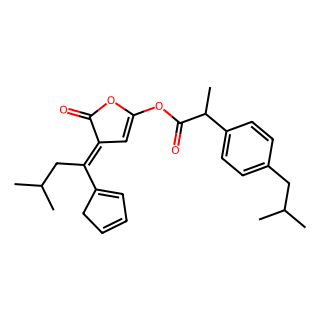

SMILES:	CC(C)CC1=CC=C(C=C1)C(C)C(=O)OC1=CC(=C(CC(C)C)C2=CC=CC2)C(=O)O1
MolWeight:	420.23005950399994
LogP:	6.159000000000007
HBD:	0.00000
HBA:	4.00000
TPSA:	52.60000000000001
NumRings:	3.00000
NumRotBonds:	8.00000
NumAtoms:	31.00000
NumHeavyAtoms:	31.00000





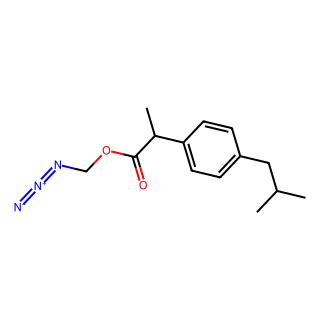

SMILES:	CC(C)CC1=CC=C(C=C1)C(C)C(=O)OCN=[N+]=[N-]
MolWeight:	261.147726848
LogP:	3.7996000000000025
HBD:	0.00000
HBA:	3.00000
TPSA:	75.06
NumRings:	1.00000
NumRotBonds:	6.00000
NumAtoms:	19.00000
NumHeavyAtoms:	19.00000





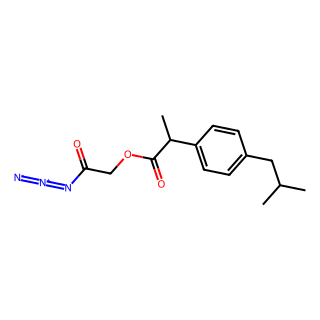

SMILES:	CC(C)CC1=CC=C(C=C1)C(C)C(=O)OCC(=O)N=[N+]=[N-]
MolWeight:	289.142641468
LogP:	3.3687000000000022
HBD:	0.00000
HBA:	3.00000
TPSA:	92.13000000000001
NumRings:	1.00000
NumRotBonds:	6.00000
NumAtoms:	21.00000
NumHeavyAtoms:	21.00000





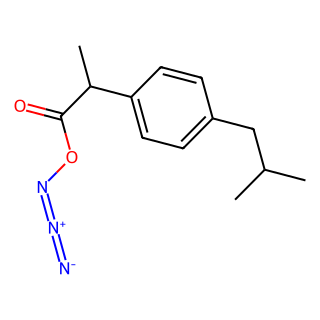

SMILES:	CC(C)CC1=CC=C(C=C1)C(C)C(=O)ON=[N+]=[N-]
MolWeight:	247.132076784
LogP:	3.757100000000003
HBD:	0.00000
HBA:	3.00000
TPSA:	75.06
NumRings:	1.00000
NumRotBonds:	5.00000
NumAtoms:	18.00000
NumHeavyAtoms:	18.00000





In [186]:
for idx, row in acceptable_mol_df[['SMILES', 'mol']].iterrows():
    smiles = row['SMILES']
    mol = row['mol']
    img = Draw.MolToImage(mol, size=(320,320))
    display(img)
    properties(row['mol'])
    print('\n\n')